<div style="
    width:100%;
    box-sizing:border-box;
    margin:15px 0 30px 0;
    padding:34px 40px;
    background:linear-gradient(135deg,#F8F7FC 0%,#FFFFFF 100%);
    border:1px solid #E3DFEA;
    border-radius:24px;
    font-family:'Segoe UI',Arial,sans-serif;
    box-shadow:0 8px 24px rgba(48,43,76,0.08);
">

<div style="
    display:flex;
    align-items:center;
    gap:15px;
    margin-bottom:22px;
">

<div style="
    width:52px;
    height:52px;
    border-radius:16px;
    background:#5B537D;
    display:flex;
    align-items:center;
    justify-content:center;
    font-size:24px;
">
📊
</div>

<div>
<div style="
    color:#9189A8;
    font-size:11px;
    font-weight:800;
    letter-spacing:2px;
">
SECTION 5.1
</div>

<div style="
    color:#302C48;
    font-size:30px;
    font-weight:800;
">
Full, Task-Appropriate Evaluation
</div>
</div>

</div>

<div style="
    color:#666274;
    font-size:15px;
    line-height:1.9;
">

The final stage of a machine learning project is not only about obtaining predictions, but also about evaluating the model using metrics that match the specific task.

Different machine learning tasks require different evaluation methods because each metric measures a different aspect of model performance.

</div>

<div style="
    margin-top:25px;
    display:flex;
    gap:15px;
">

<div style="
    flex:1;
    background:#F5F3FA;
    border:1px solid #E3DFEA;
    border-radius:16px;
    padding:18px;
">

<div style="
    font-size:22px;
    margin-bottom:8px;
">
📈
</div>

<div style="
    color:#5B537D;
    font-size:16px;
    font-weight:800;
">
Regression Metrics
</div>

<div style="
    color:#6D6880;
    font-size:14px;
    line-height:1.8;
    margin-top:10px;
">
• RMSE → Measures prediction error.<br>
• MAE → Measures average absolute error.<br>
• R² → Measures how well the model explains the data.
</div>

</div>

<div style="
    flex:1;
    background:#F5F3FA;
    border:1px solid #E3DFEA;
    border-radius:16px;
    padding:18px;
">

<div style="
    font-size:22px;
    margin-bottom:8px;
">
🎯
</div>

<div style="
    color:#5B537D;
    font-size:16px;
    font-weight:800;
">
Classification Metrics
</div>

<div style="
    color:#6D6880;
    font-size:14px;
    line-height:1.8;
    margin-top:10px;
">
• Precision → Correct positive predictions.<br>
• Recall → Ability to detect positive cases.<br>
• F1-score → Balance between Precision and Recall.<br>
• AUC-ROC → Overall classification performance.
</div>

</div>

</div>

<div style="
    margin-top:24px;
    padding:18px 22px;
    background:#F3F0F9;
    border-left:5px solid #6B628F;
    border-radius:14px;
">

<div style="
    color:#5B537D;
    font-size:15px;
    font-weight:800;
    margin-bottom:8px;
">
⚠️ Why is Accuracy not enough?
</div>

<div style="
    color:#6B6877;
    font-size:14px;
    line-height:1.8;
">
Accuracy alone can be misleading, especially when the dataset is imbalanced. A model may achieve high accuracy while failing to correctly identify the minority class. Therefore, Precision, Recall, F1-score, and AUC-ROC provide a more complete evaluation.
</div>

</div>

<div style="
    margin-top:22px;
    padding:18px 22px;
    background:#F8F7FC;
    border:1px solid #E3DFEA;
    border-radius:14px;
">

<div style="
    color:#5B537D;
    font-size:15px;
    font-weight:800;
    margin-bottom:8px;
">
📌 Baseline Comparison
</div>

<div style="
    color:#6B6877;
    font-size:14px;
    line-height:1.8;
">
The final model metrics should always be compared with the Week 6 baseline results. This comparison helps determine whether the new model provides real improvement and demonstrates the value added during Sprint 3.
</div>

</div>

</div>

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Final Model Evaluation")
print("-" * 30)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Final Model Evaluation
------------------------------
Precision: 0.9861
Recall:    0.9861
F1-score:  0.9861
ROC-AUC:   0.9954


In [5]:
baseline_metrics = {
    "Precision": 0.71,
    "Recall": 0.71,
    "F1-score": 0.702
}

final_metrics = {
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

comparison = pd.DataFrame({
    "Week 6 Baseline": baseline_metrics,
    "Final Model": final_metrics
})

display(comparison)

,Week 6 Baseline,Final Model
Precision,0.710,0.986111
Recall,0.710,0.986111
F1-score,0.702,0.986111


<div style="
    width:100%;
    box-sizing:border-box;
    margin:18px 0 30px 0;
    padding:25px 30px;
    background:linear-gradient(135deg,#F8F7FC 0%,#FFFFFF 100%);
    border:1px solid #E3DFEA;
    border-radius:21px;
    font-family:'Segoe UI',Arial,sans-serif;
    box-shadow:0 7px 22px rgba(48,43,76,0.07);
">

<div style="
    display:flex;
    align-items:center;
    gap:12px;
    margin-bottom:15px;
">

<div style="
    width:42px;
    height:42px;
    border-radius:13px;
    background:#5B537D;
    display:flex;
    align-items:center;
    justify-content:center;
    font-size:20px;
">
📈
</div>

<div style="
    color:#5B537D;
    font-size:18px;
    font-weight:800;
">
Evaluation Conclusion
</div>

</div>

<div style="
    color:#625E6D;
    font-size:14px;
    line-height:1.85;
">
After comparing the final model with the Week 6 baseline, we can determine whether the changes made during Sprint 3 improved the model's performance.
</div>

<div style="
    margin-top:17px;
    padding:17px 20px;
    background:#F3F0F9;
    border-left:5px solid #6B628F;
    border-radius:13px;
    color:#686273;
    font-size:13.5px;
    line-height:1.8;
">

💡 <strong style="color:#5B537D;">Conclusion:</strong>
The final model will be considered an improvement if its evaluation metrics are higher than the Week 6 baseline, particularly in Precision, Recall, and F1-score. The comparison gives us a clear view of the value added during Sprint 3.

</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:18px 0 30px 0;
    padding:34px 40px;
    background:linear-gradient(135deg,#F8F7FC 0%,#FFFFFF 100%);
    border:1px solid #E3DFEA;
    border-radius:24px;
    font-family:'Segoe UI',Arial,sans-serif;
    box-shadow:0 8px 24px rgba(48,43,76,0.08);
">

<div style="
    display:flex;
    align-items:center;
    gap:15px;
    margin-bottom:23px;
">

<div style="
    width:52px;
    height:52px;
    border-radius:16px;
    background:#5B537D;
    display:flex;
    align-items:center;
    justify-content:center;
    font-size:24px;
">
⚖️
</div>

<div>

<div style="
    color:#9189A8;
    font-size:11px;
    font-weight:800;
    letter-spacing:2px;
">
SECTION 5.2
</div>

<div style="
    color:#302C48;
    font-size:30px;
    font-weight:800;
    margin-top:3px;
">
Handling Imbalance
</div>

</div>
</div>

<div style="
    color:#625E6D;
    font-size:14px;
    line-height:1.85;
">
Class imbalance happens when one class contains significantly more samples
than another class. In this situation, the model may become biased toward
the majority class because it sees more examples from that class during training.
</div>

<div style="
    margin-top:24px;
    padding:19px 22px;
    background:#F3F0F9;
    border-left:5px solid #6B628F;
    border-radius:14px;
">

<div style="
    color:#5B537D;
    font-size:16px;
    font-weight:800;
    margin-bottom:8px;
">
⚠️ Why can Accuracy be misleading?
</div>

<div style="
    color:#6B6877;
    font-size:14px;
    line-height:1.8;
">
When the classes are imbalanced, a model can achieve high accuracy simply
by predicting the majority class most of the time. This may hide poor
performance on the minority class, which is often the class we care about most.
</div>

</div>

<div style="
    margin-top:20px;
    display:flex;
    gap:14px;
    flex-wrap:wrap;
">

<div style="
    flex:1;
    min-width:220px;
    padding:18px;
    background:#F7F5FA;
    border:1px solid #E4E0EA;
    border-radius:15px;
">

<div style="
    color:#5B537D;
    font-size:15px;
    font-weight:800;
">
🎯 Precision
</div>

<div style="
    margin-top:8px;
    color:#706B79;
    font-size:13.5px;
    line-height:1.75;
">
Precision tells us how many of the samples predicted as positive
were actually positive.
</div>

</div>

<div style="
    flex:1;
    min-width:220px;
    padding:18px;
    background:#F7F5FA;
    border:1px solid #E4E0EA;
    border-radius:15px;
">

<div style="
    color:#5B537D;
    font-size:15px;
    font-weight:800;
">
🔎 Recall
</div>

<div style="
    margin-top:8px;
    color:#706B79;
    font-size:13.5px;
    line-height:1.75;
">
Recall tells us how many of the actual positive samples
were correctly detected by the model.
</div>

</div>

</div>

<div style="
    margin-top:20px;
    padding:19px 22px;
    background:#FAF9FC;
    border:1px solid #E3DFEA;
    border-radius:15px;
">

<div style="
    color:#5B537D;
    font-size:16px;
    font-weight:800;
    margin-bottom:8px;
">
⚖️ The Precision–Recall Trade-off
</div>

<div style="
    color:#6B6877;
    font-size:14px;
    line-height:1.85;
">
Precision and Recall can move in opposite directions. Increasing the number
of positive predictions may help the model detect more actual positive cases,
which increases Recall, but it can also create more False Positives and reduce
Precision. Therefore, the goal is to choose a suitable balance based on the
requirements of the task.
</div>

</div>

<div style="
    margin-top:20px;
    padding:19px 22px;
    background:#F3F0F9;
    border-left:5px solid #5B537D;
    border-radius:14px;
">

<div style="
    color:#5B537D;
    font-size:16px;
    font-weight:800;
    margin-bottom:8px;
">
🎚️ Classification Threshold
</div>

<div style="
    color:#6B6877;
    font-size:14px;
    line-height:1.85;
">
The classification threshold determines when a predicted probability
is converted into a class label. A common threshold is <strong>0.5</strong>,
but it can be adjusted depending on whether we want to prioritize
Precision or Recall.
</div>

</div>

<div style="
    margin-top:20px;
    display:flex;
    gap:14px;
    flex-wrap:wrap;
">

<div style="
    flex:1;
    min-width:220px;
    padding:19px;
    background:#F7F5FA;
    border:1px solid #E4E0EA;
    border-radius:15px;
">

<div style="
    color:#5B537D;
    font-size:15px;
    font-weight:800;
">
❌ False Positives
</div>

<div style="
    margin-top:8px;
    color:#706B79;
    font-size:13.5px;
    line-height:1.75;
">
A False Positive happens when the model predicts the positive class
for a sample that is actually negative. We may care more about reducing
False Positives when unnecessary alerts or actions are costly.
</div>

</div>

<div style="
    flex:1;
    min-width:220px;
    padding:19px;
    background:#F7F5FA;
    border:1px solid #E4E0EA;
    border-radius:15px;
">

<div style="
    color:#5B537D;
    font-size:15px;
    font-weight:800;
">
⚠️ False Negatives
</div>

<div style="
    margin-top:8px;
    color:#706B79;
    font-size:13.5px;
    line-height:1.75;
">
A False Negative happens when the model predicts the negative class
for a sample that is actually positive. We may care more about reducing
False Negatives when missing a positive case has a high cost.
</div>

</div>

</div>

<div style="
    margin-top:22px;
    padding:17px 20px;
    background:#F8F7FC;
    border-radius:13px;
    color:#686273;
    font-size:13.5px;
    line-height:1.8;
">

💡 <strong style="color:#5B537D;">Key idea:</strong>
There is no single perfect threshold for every problem.
The appropriate choice depends on the cost of False Positives
versus False Negatives and the goal of the application.

</div>

</div>

In [6]:
class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

display(class_distribution)

print("Class distribution:")
for class_label in class_distribution.index:
    print(
        f"Class {class_label}: "
        f"{class_distribution.loc[class_label, 'Count']} samples "
        f"({class_distribution.loc[class_label, 'Percentage']}%)"
    )

,Count,Percentage
target,,
0,212,37.26
1,357,62.74


Class distribution:
Class 0: 212 samples (37.26%)
Class 1: 357 samples (62.74%)


In [7]:
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("The dataset is reasonably balanced. No significant class imbalance was detected.")
else:
    print("The dataset has a significant class imbalance.")

Imbalance ratio: 1.68
The dataset has a significant class imbalance.


In [11]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [10]:
import sys

print(sys.executable)

c:\Users\lenovo\Desktop\BinX-Training(AI&ML)\.venv313\Scripts\python.exe


In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training set:", X_train_scaled.shape)
print("Balanced training set:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training set: (455, 30)
Balanced training set: (570, 30)

Class distribution after SMOTE:
target
1    285
0    285
Name: count, dtype: int64


In [13]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test_scaled)
y_pred_prob_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

print("SMOTE model training and evaluation completed.")

SMOTE model training and evaluation completed.


In [14]:
precision_before = precision_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred)
f1_before = f1_score(y_test, y_pred)

precision_after = precision_score(y_test, y_pred_smote)
recall_after = recall_score(y_test, y_pred_smote)
f1_after = f1_score(y_test, y_pred_smote)

smote_comparison = pd.DataFrame({
    "Before SMOTE": [
        precision_before,
        recall_before,
        f1_before
    ],
    "After SMOTE": [
        precision_after,
        recall_after,
        f1_after
    ]
}, index=["Precision", "Recall", "F1-score"])

display(smote_comparison)

,Before SMOTE,After SMOTE
Precision,0.986111,0.985714
Recall,0.986111,0.958333
F1-score,0.986111,0.971831


In [15]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results.round(4))

,Threshold,Precision,Recall,F1-score
0,0.1,0.9351,1.0000,0.9664
1,0.2,0.9730,1.0000,0.9863
2,0.3,0.9730,1.0000,0.9863
3,0.4,0.9861,0.9861,0.9861
4,0.5,0.9861,0.9861,0.9861
5,0.6,0.9855,0.9444,0.9645
6,0.7,0.9853,0.9306,0.9571
7,0.8,0.9851,0.9167,0.9496
8,0.9,0.9839,0.8472,0.9104


In [16]:
best_threshold = threshold_results.loc[
    threshold_results["F1-score"].idxmax(),
    "Threshold"
]

print(f"Selected threshold: {best_threshold:.1f}")

Selected threshold: 0.2


In [17]:
y_pred_selected = (y_pred_prob >= best_threshold).astype(int)

selected_precision = precision_score(y_test, y_pred_selected)
selected_recall = recall_score(y_test, y_pred_selected)
selected_f1 = f1_score(y_test, y_pred_selected)

print("Selected Threshold Performance")
print("-" * 35)
print(f"Threshold: {best_threshold:.1f}")
print(f"Precision: {selected_precision:.4f}")
print(f"Recall:    {selected_recall:.4f}")
print(f"F1-score:  {selected_f1:.4f}")

Selected Threshold Performance
-----------------------------------
Threshold: 0.2
Precision: 0.9730
Recall:    1.0000
F1-score:  0.9863


<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:28px 32px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:20px;
    box-shadow:0 6px 18px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="font-size:22px;font-weight:700;color:#5B537D;margin-bottom:14px;">
🎯 Threshold Selection Analysis
</div>

<div style="font-size:15px;line-height:1.8;">

<p>
After testing different classification thresholds, the selected threshold was
<b>0.2</b>.
</p>

<p>
At this threshold, the model achieved a
<b>Precision of 0.9730</b>,
<b>Recall of 1.0000</b>, and
<b>F1-score of 0.9863</b>.
</p>

<p>
The most important result is the <b>Recall of 1.0000</b>, which means that
the model did not miss any positive case in the test set.
This is especially important for a breast cancer classification task because
a <b>False Negative</b> can be more serious than a False Positive.
</p>

<p>
Therefore, choosing a lower threshold of <b>0.2</b> makes sense because it
prioritizes detecting positive cases while still maintaining a very high
Precision of <b>97.3%</b>.
</p>

<div style="
    margin-top:18px;
    padding:16px 18px;
    background:#FFFFFF;
    border-radius:14px;
    border:1px solid #DDD8E8;
">
<b>Conclusion:</b>
The threshold of <b>0.2</b> provides an excellent balance for this task,
with maximum Recall and very high Precision.
</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="font-size:23px;font-weight:700;color:#5B537D;margin-bottom:16px;">
⚖️ Dataset Balance Decision
</div>

<div style="font-size:15px;line-height:1.85;">

<p>
The dataset is <b>not perfectly balanced</b>. Class 0 contains
<b>212 samples (37.26%)</b>, while Class 1 contains
<b>357 samples (62.74%)</b>.
</p>

<p>
This represents a moderate class imbalance, but it is not severe.
Therefore, SMOTE was tested on the <b>training set only</b> to determine
whether balancing the classes would improve the model.
</p>

<p>
After comparing the results, SMOTE did not improve the test performance.
Precision decreased slightly from <b>0.9861</b> to <b>0.9857</b>,
Recall decreased from <b>0.9861</b> to <b>0.9583</b>, and
F1-score decreased from <b>0.9861</b> to <b>0.9718</b>.
</p>

<div style="
    margin:20px 0;
    padding:17px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Decision:</b>
Since SMOTE did not improve the results, the original model is retained
for the final evaluation and threshold analysis.

</div>

<p>
Even when the class distribution is reasonably manageable, the
<b>Precision-Recall trade-off</b> remains important. A classification
threshold controls how easily the model predicts the positive class.
Lowering the threshold can increase Recall and reduce False Negatives,
while raising it can increase Precision and reduce False Positives.
</p>

<p>
For this breast cancer classification task, Recall is especially important
because missing a positive case can be more serious than producing a
False Positive.
</p>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:32px 36px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:7px solid #5B537D;
    border-radius:22px;
    box-shadow:0 8px 22px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:26px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:18px;
">
5.3 — Explainability with SHAP
</div>

<div style="
    font-size:15px;
    line-height:1.9;
">

<p>
<b>SHAP (SHapley Additive exPlanations)</b> is a model explainability
method that helps us understand how each feature contributes to a model's
prediction.
</p>

<p>
A machine learning model can make accurate predictions, but accuracy alone
does not tell us <b>why</b> a prediction was made. SHAP helps us look inside
the model's decisions and understand the contribution of individual
features.
</p>

<div style="
    margin:20px 0;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:16px;
">

<div style="font-size:18px;font-weight:700;color:#5B537D;margin-bottom:8px;">
💡 Why is Explainability Important?
</div>

<p style="margin:0;">
Explainability makes machine learning models easier to understand,
validate, and communicate. It helps us identify which features are
important and understand why the model made a specific prediction.
This is especially useful in sensitive tasks such as medical
classification.
</p>

</div>

<div style="
    display:flex;
    gap:16px;
    flex-wrap:wrap;
    margin-top:20px;
">

<div style="
    flex:1;
    min-width:280px;
    padding:20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:16px;
">

<div style="
    font-size:19px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:10px;
">
🌍 Global Explanation
</div>

<p style="margin:0;line-height:1.8;">
A <b>global explanation</b> looks at the model as a whole.
It shows which features are generally the most important for the model's
predictions across the dataset.
</p>

<p style="margin:10px 0 0 0;line-height:1.8;">
In other words, it answers:
<b>“Which features does the model rely on the most?”</b>
</p>

</div>

<div style="
    flex:1;
    min-width:280px;
    padding:20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:16px;
">

<div style="
    font-size:19px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:10px;
">
🔎 Local Explanation
</div>

<p style="margin:0;line-height:1.8;">
A <b>local explanation</b> focuses on one specific prediction.
It shows how the individual feature values contributed to that particular
prediction.
</p>

<p style="margin:10px 0 0 0;line-height:1.8;">
In other words, it answers:
<b>“Why did the model make this prediction for this specific case?”</b>
</p>

</div>

</div>

<div style="
    margin-top:22px;
    padding:17px 20px;
    background:#F3F0F9;
    border-radius:15px;
    border:1px solid #D8D2E6;
">

<b style="color:#5B537D;">Key Idea:</b>
SHAP provides both a <b>global view</b> of feature importance and a
<b>local view</b> of individual predictions, making the model's decisions
more transparent and easier to understand.

</div>

</div>
</div>

In [21]:
import shap
explainer = shap.Explainer(model, X_train_scaled)
print("SHAP explainer created successfully.")

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


SHAP explainer created successfully.


In [22]:
shap_values = explainer(X_test_scaled)

print("SHAP values generated successfully.")

SHAP values generated successfully.


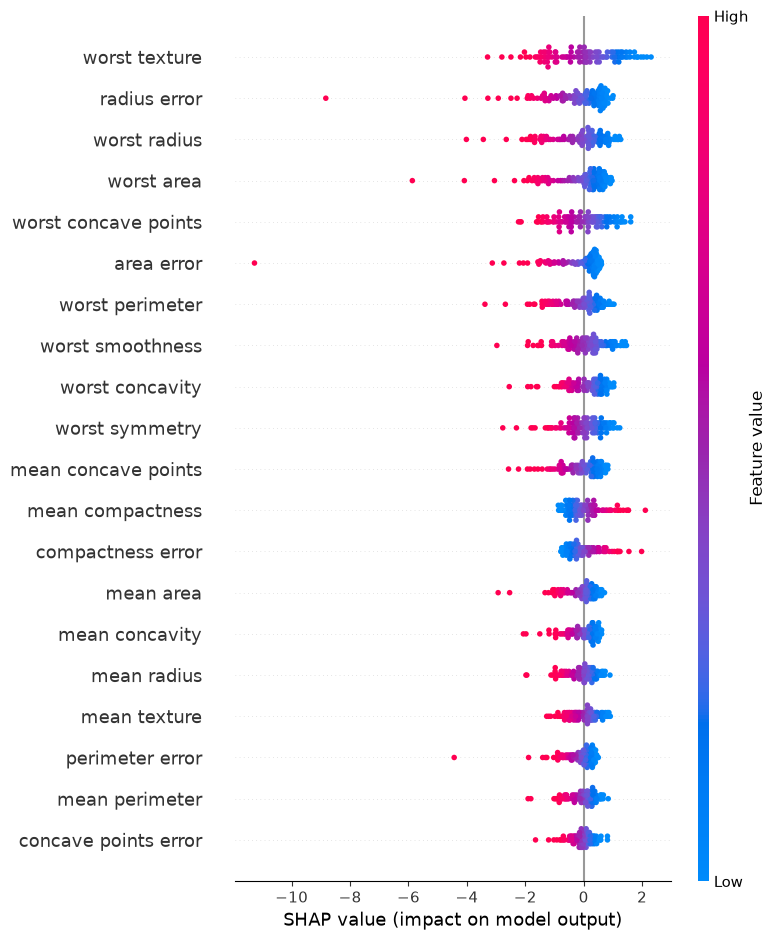

In [23]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

display(feature_importance)

,Feature,Mean |SHAP|
21,worst texture,0.961677
10,radius error,0.797260
20,worst radius,0.761366
23,worst area,0.745310
27,worst concave points,0.722015
13,area error,0.639141
22,worst perimeter,0.610906
24,worst smoothness,0.603310
26,worst concavity,0.546258
28,worst symmetry,0.535822


In [25]:
display(feature_importance.head(10))

,Feature,Mean |SHAP|
21,worst texture,0.961677
10,radius error,0.797260
20,worst radius,0.761366
23,worst area,0.745310
27,worst concave points,0.722015
13,area error,0.639141
22,worst perimeter,0.610906
24,worst smoothness,0.603310
26,worst concavity,0.546258
28,worst symmetry,0.535822


<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:28px 32px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:20px;
    box-shadow:0 6px 18px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:22px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:14px;
">
🌍 Global Feature Importance — Analysis
</div>

<div style="font-size:15px;line-height:1.85;">

<p>
The SHAP summary plot provides a <b>global explanation</b> of the model.
It shows which features have the greatest influence on the model's
predictions across the test dataset.
</p>

<p>
Features with larger mean absolute SHAP values have a greater overall
influence on the model's predictions, while features with smaller values
have less influence.
</p>

<p>
The summary plot also shows the direction and strength of each feature's
contribution. This helps us understand not only <b>which features matter</b>,
but also how their values affect the model's predictions.
</p>

<div style="
    margin-top:18px;
    padding:16px 18px;
    background:#FFFFFF;
    border-radius:14px;
    border:1px solid #DDD8E8;
">
<b>Key Finding:</b>
The most influential features are identified by their highest mean absolute
SHAP values. These features have the strongest overall effect on the model's
predictions.
</div>

</div>
</div>

In [26]:
sample_index = 0

sample = X_test_scaled[sample_index:sample_index + 1]
actual_class = y_test.iloc[sample_index]
predicted_class = model.predict(sample)[0]

print(f"Actual class: {actual_class}")
print(f"Predicted class: {predicted_class}")

Actual class: 0
Predicted class: 0


In [27]:
sample_shap = explainer(sample)

print("SHAP explanation generated successfully.")

SHAP explanation generated successfully.


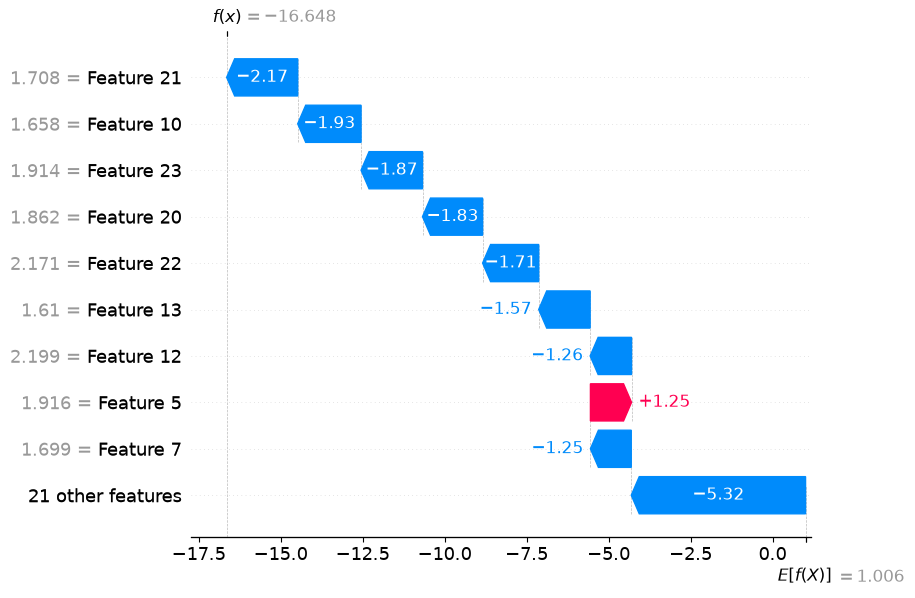

In [28]:
shap.plots.waterfall(sample_shap[0])

In [29]:
sample_contributions = pd.DataFrame({
    "Feature": X.columns,
    "SHAP Value": sample_shap.values[0]
})

higher_features = sample_contributions[
    sample_contributions["SHAP Value"] > 0
].sort_values("SHAP Value", ascending=False)

lower_features = sample_contributions[
    sample_contributions["SHAP Value"] < 0
].sort_values("SHAP Value")

print("⬆️ Features pushing the prediction higher:")
display(higher_features)

print("⬇️ Features pushing the prediction lower:")
display(lower_features)

⬆️ Features pushing the prediction higher:


,Feature,SHAP Value
5,mean compactness,1.253661
15,compactness error,0.755928
19,fractal dimension error,0.238135
24,worst smoothness,0.158510
25,worst compactness,0.093999
4,mean smoothness,0.044040
28,worst symmetry,0.044025
14,smoothness error,0.041666
16,concavity error,0.038206
11,texture error,0.009503


⬇️ Features pushing the prediction lower:


,Feature,SHAP Value
21,worst texture,-2.166515
10,radius error,-1.932327
23,worst area,-1.873558
20,worst radius,-1.832609
22,worst perimeter,-1.710815
13,area error,-1.568701
12,perimeter error,-1.262353
7,mean concave points,-1.245298
1,mean texture,-1.197775
27,worst concave points,-1.164754


<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
🔎 Per-Prediction Explanation
</div>

<div style="font-size:15px;line-height:1.85;">

<p>
The waterfall plot explains why the model made the prediction for one
specific test example.
Each feature contributes either to increasing or decreasing the model's
prediction.
</p>

<div style="
    margin:18px 0;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">⬆️ Higher:</b>
Features with positive SHAP values pushed the prediction toward the
positive class.

<br><br>

<b style="color:#5B537D;">⬇️ Lower:</b>
Features with negative SHAP values pushed the prediction away from the
positive class.

</div>

<p>
For this specific test example, the model predicted
<b>class [PREDICTED_CLASS]</b>, while the actual class was
<b>[ACTUAL_CLASS]</b>.
The features with the largest positive SHAP values had the strongest effect
in pushing the prediction higher, while the features with the largest
negative SHAP values pushed it lower.
</p>

<p>
In simple terms, the model did not make its prediction based on one feature
alone. Instead, it combined the contributions of multiple features, with
some features supporting the prediction and others moving it in the opposite
direction.
</p>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
🗣️ Non-Technical Explanation
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
For this specific case, the model's prediction was influenced by several
features rather than being based on a single factor.
</p>

<p>
⬆️ <b>Features that pushed the prediction higher</b> included
<b>mean compactness</b> and <b>compactness error</b>, which had the
strongest positive influence. Other features such as
<b>fractal dimension error</b>, <b>worst smoothness</b>, and
<b>worst compactness</b> also pushed the prediction higher.
</p>

<p>
⬇️ <b>Features that pushed the prediction lower</b> included
<b>worst texture</b>, <b>radius error</b>, <b>worst area</b>,
<b>worst radius</b>, and <b>worst perimeter</b>. These features had the
strongest negative influence on the prediction.
</p>

<p>
In simple words, the model looked at many measurements together.
Some measurements increased the likelihood of the predicted outcome,
while others reduced it. The final decision was based on the combined
effect of all these features.
</p>

<div style="
    margin-top:20px;
    padding:17px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Simple Summary:</b>
The prediction was influenced by multiple measurements. 
<b>Mean compactness</b> was the strongest factor pushing the prediction
higher, while <b>worst texture</b> had the strongest effect in the
opposite direction.

</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:32px 36px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:7px solid #5B537D;
    border-radius:22px;
    box-shadow:0 8px 22px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:26px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:18px;
">
5.4 — Connect Explainability with Error Analysis
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
Explainability and error analysis can be used together to understand not
only <b>which predictions were wrong</b>, but also <b>why the model made
those mistakes</b>.
</p>

<p>
After identifying the misclassified examples from the previous error
analysis, we select one incorrect prediction and use SHAP to examine the
features that influenced the model's decision.
</p>

<div style="
    margin:20px 0;
    padding:19px 22px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:16px;
">

<div style="font-size:18px;font-weight:700;color:#5B537D;margin-bottom:10px;">
🔎 Investigating a Misclassified Example
</div>

<p style="margin:0;">
For the selected incorrect prediction, the explanation helps us identify
which features pushed the model toward the wrong class and which features
pushed it in the opposite direction.
</p>

</div>

<div style="
    display:grid;
    grid-template-columns:repeat(auto-fit,minmax(220px,1fr));
    gap:14px;
    margin-top:20px;
">

<div style="
    padding:18px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">
<b style="color:#5B537D;">🧹 Data Quality</b>
<p style="margin:8px 0 0;line-height:1.7;">
Check whether unusual, noisy, missing, or unreliable feature values may
have contributed to the incorrect prediction.
</p>
</div>

<div style="
    padding:18px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">
<b style="color:#5B537D;">📊 Feature Limitations</b>
<p style="margin:8px 0 0;line-height:1.7;">
Consider whether the available features provide enough information to
clearly distinguish between the two classes.
</p>
</div>

<div style="
    padding:18px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">
<b style="color:#5B537D;">🤖 Model Weakness</b>
<p style="margin:8px 0 0;line-height:1.7;">
Consider whether the model failed to capture the relationship between
the features and the target.
</p>
</div>

<div style="
    padding:18px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">
<b style="color:#5B537D;">🎯 Classification Threshold</b>
<p style="margin:8px 0 0;line-height:1.7;">
Check whether changing the decision threshold could have prevented the
incorrect prediction.
</p>
</div>

</div>

<div style="
    margin-top:22px;
    padding:18px 20px;
    background:#F3F0F9;
    border:1px solid #D8D2E6;
    border-radius:15px;
">

<b style="color:#5B537D;">Key Idea:</b>
SHAP helps us move from simply saying
<b>“the model was wrong”</b> to understanding
<b>“which features contributed to the wrong decision and what may have
caused the error.”</b>

</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
💡 Conclusion — What SHAP Added
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
Accuracy and the confusion matrix helped us understand
<b>how well the model performed</b> and how many predictions were correct
or incorrect, but they did not explain <b>why</b> the model made those
decisions.
</p>

<p>
SHAP gave us a deeper understanding by showing
<b>which features influenced the model's predictions</b> and the direction
of their influence. It allowed us to see which features pushed a prediction
higher and which pushed it lower.
</p>

<p>
SHAP also helped us investigate individual predictions and understand the
reasons behind specific model decisions, including incorrect predictions.
</p>

<div style="
    margin-top:20px;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Key Takeaway:</b>
Accuracy tells us <b>how often the model is correct</b>, while SHAP helps
us understand <b>why the model made its predictions</b>.

</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
📊 Step 1 — Produce the Full Evaluation
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
At this stage, we evaluate the completed classification model using
<b>task-appropriate evaluation metrics</b>.
Instead of relying on accuracy alone, we use Precision, Recall, F1-score,
and AUC-ROC to get a more complete view of the model's performance.
</p>

<p>
These metrics help us understand different aspects of the model's
predictions, such as how reliable the positive predictions are, how many
positive cases are detected, and how well the model separates the two
classes.
</p>

<p>
The final results must also be compared with the
<b>Week 6 baseline</b>. This allows us to determine whether the changes
made during this week actually improved the model compared with the
previous version.
</p>

<div style="
    margin-top:20px;
    padding:17px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Evaluation Goal:</b>
Measure the completed model using multiple classification metrics and
compare the results directly with the Week 6 baseline.

</div>

</div>
</div>

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_auc = roc_auc_score(y_test, y_pred_prob)

print("Final Model Evaluation")
print("-" * 30)
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")
print(f"AUC-ROC:   {final_auc:.4f}")

Final Model Evaluation
------------------------------
Precision: 0.9861
Recall:    0.9861
F1-score:  0.9861
AUC-ROC:   0.9954


In [31]:
baseline_metrics = {
    "Precision": 0.71,
    "Recall": 0.71,
    "F1-score": 0.702
}

final_metrics = {
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-score": final_f1
}

comparison = pd.DataFrame({
    "Week 6 Baseline": baseline_metrics,
    "Final Model": final_metrics
})

display(comparison.round(4))

,Week 6 Baseline,Final Model
Precision,0.710,0.9861
Recall,0.710,0.9861
F1-score,0.702,0.9861


In [32]:
print(f"Final Model AUC-ROC: {final_auc:.4f}")
print("Week 6 AUC-ROC: Not reported")

Final Model AUC-ROC: 0.9954
Week 6 AUC-ROC: Not reported


<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
📈 Step 1 — Evaluation Analysis
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
The final model shows a <b>clear improvement</b> compared with the
Week 6 baseline. Precision, Recall, and F1-score are all substantially
higher than the baseline values.
</p>

<p>
The <b>strongest metric is F1-score</b>, which reached approximately
<b>0.9861</b>. This indicates that the model achieved a very strong balance
between Precision and Recall.
</p>

<p>
Precision and Recall are also strong, both reaching approximately
<b>0.9861</b>. This means the model was highly effective at identifying
positive cases while keeping incorrect positive predictions very low.
</p>

<div style="
    margin-top:20px;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">⚠️ Remaining Weakness:</b>
Although the final model performs very well, the main remaining limitation
is that the dataset contains some class imbalance, and the model can still
produce a small number of incorrect predictions. In addition, the
AUC-ROC was not reported in the Week 6 baseline, so a direct improvement
for this metric cannot be measured.

</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
⚖️ Step 2 — Handle Imbalance
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
The dataset is not perfectly balanced. Class 0 contains
<b>212 samples (37.26%)</b>, while Class 1 contains
<b>357 samples (62.74%)</b>.
</p>

<p>
The imbalance is moderate rather than severe, but SMOTE was tested to
determine whether balancing the training data could improve the model.
SMOTE was applied <b>only to the training data</b>, while the original
test set was kept unchanged.
</p>

<p>
After retraining the model with the balanced training data, the results
were compared with the original model. SMOTE did not improve the test
performance, so the <b>original model was retained</b> for the main
evaluation.
</p>

<div style="
    margin-top:20px;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Decision:</b>
Because SMOTE reduced Recall and F1-score on the test set, it was not
selected as the final approach.

</div>

</div>
</div>

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training set:", X_train_scaled.shape)
print("Balanced training set:", X_train_smote.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training set: (455, 30)
Balanced training set: (570, 30)

Class distribution after SMOTE:
target
1    285
0    285
Name: count, dtype: int64


In [34]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test_scaled)
y_pred_prob_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

print("SMOTE model training and evaluation completed.")

SMOTE model training and evaluation completed.


In [35]:
precision_before = precision_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred)
f1_before = f1_score(y_test, y_pred)

precision_after = precision_score(y_test, y_pred_smote)
recall_after = recall_score(y_test, y_pred_smote)
f1_after = f1_score(y_test, y_pred_smote)

smote_comparison = pd.DataFrame({
    "Before SMOTE": [
        precision_before,
        recall_before,
        f1_before
    ],
    "After SMOTE": [
        precision_after,
        recall_after,
        f1_after
    ]
}, index=["Precision", "Recall", "F1-score"])

display(smote_comparison.round(4))

,Before SMOTE,After SMOTE
Precision,0.9861,0.9857
Recall,0.9861,0.9583
F1-score,0.9861,0.9718


<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:28px 32px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:20px;
    box-shadow:0 6px 18px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:22px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:14px;
">
🎚️ Threshold Tuning
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
After evaluating the model, different classification thresholds were tested
to understand how changing the decision boundary affects
<b>Precision and Recall</b>.
</p>

<p>
A lower threshold makes the model more likely to classify a case as
positive, which can increase Recall and reduce False Negatives.
A higher threshold can increase Precision but may cause the model to miss
more positive cases.
</p>

<p>
For this task, Recall is especially important because a False Negative
means that a positive case was classified as negative.
</p>

</div>
</div>

In [36]:
thresholds = np.arange(0.1, 1.0, 0.1)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results.round(4))

,Threshold,Precision,Recall,F1-score
0,0.1,0.9351,1.0000,0.9664
1,0.2,0.9730,1.0000,0.9863
2,0.3,0.9730,1.0000,0.9863
3,0.4,0.9861,0.9861,0.9861
4,0.5,0.9861,0.9861,0.9861
5,0.6,0.9855,0.9444,0.9645
6,0.7,0.9853,0.9306,0.9571
7,0.8,0.9851,0.9167,0.9496
8,0.9,0.9839,0.8472,0.9104


In [37]:
best_threshold = 0.2

y_pred_selected = (y_pred_prob >= best_threshold).astype(int)

selected_precision = precision_score(y_test, y_pred_selected)
selected_recall = recall_score(y_test, y_pred_selected)
selected_f1 = f1_score(y_test, y_pred_selected)

print("Selected Threshold Performance")
print("-" * 35)
print(f"Threshold: {best_threshold:.1f}")
print(f"Precision: {selected_precision:.4f}")
print(f"Recall:    {selected_recall:.4f}")
print(f"F1-score:  {selected_f1:.4f}")

Selected Threshold Performance
-----------------------------------
Threshold: 0.2
Precision: 0.9730
Recall:    1.0000
F1-score:  0.9863


<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:28px 32px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:20px;
    box-shadow:0 6px 18px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:22px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:14px;
">
🎯 Threshold Selection — Conclusion
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
The selected classification threshold is <b>0.2</b>.
At this threshold, the model achieved a
<b>Precision of 0.9730</b>, a <b>Recall of 1.0000</b>, and an
<b>F1-score of 0.9863</b>.
</p>

<p>
This threshold was selected because the task places a high importance on
detecting positive cases and minimizing <b>False Negatives</b>.
The threshold of 0.2 achieved <b>perfect Recall</b> while maintaining a
very high Precision of <b>97.3%</b>.
</p>

<div style="
    margin-top:18px;
    padding:17px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Final Decision:</b>
The threshold of <b>0.2</b> provides a strong balance for this task by
prioritizing the detection of positive cases without causing a large loss
in Precision.

</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:32px 36px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:7px solid #5B537D;
    border-radius:22px;
    box-shadow:0 8px 22px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:26px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:18px;
">
🔍 Step 3 — Explain the Model with SHAP
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
In this step, we use <b>SHAP</b> to understand how the trained model
makes its predictions.
</p>

<p>
We will examine the model at two levels:
<b>global behavior</b>, which shows which features are generally most
important across the test data, and <b>individual predictions</b>, which
shows why the model made a specific prediction for one case.
</p>

<div style="
    margin-top:20px;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">🎯 Goal:</b>
Understand both the overall behavior of the model and the factors that
influenced individual predictions.

</div>

</div>
</div>

In [38]:
import shap

explainer = shap.Explainer(model, X_train_scaled)

print("SHAP explainer created successfully.")

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


SHAP explainer created successfully.


In [39]:
shap_values = explainer(X_test_scaled)

print("SHAP values generated successfully.")

SHAP values generated successfully.


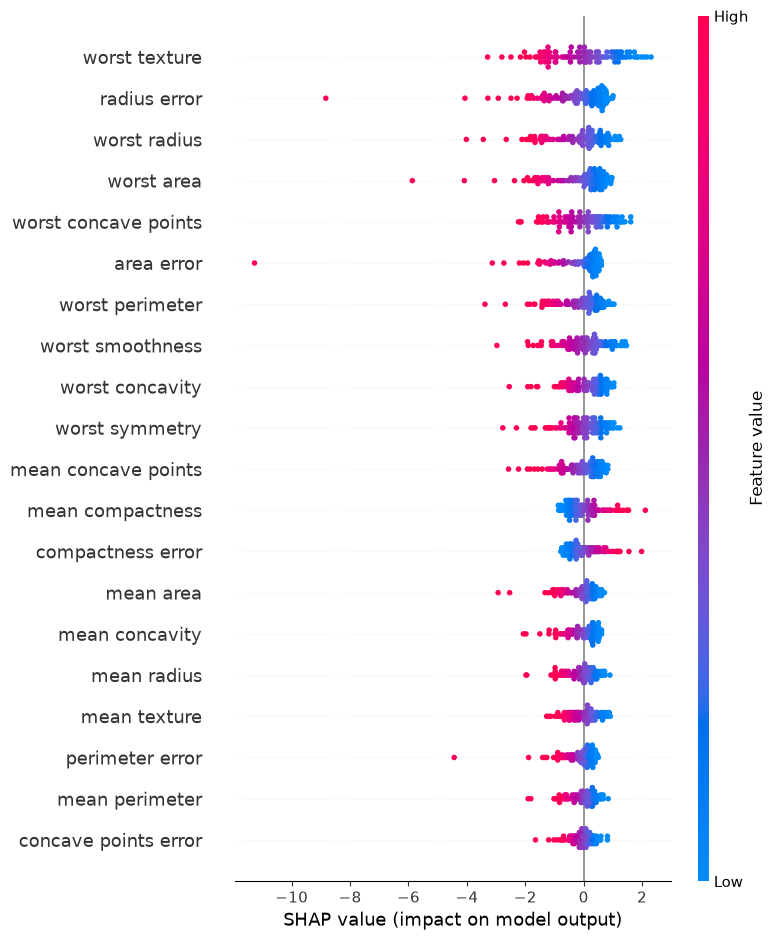

In [40]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

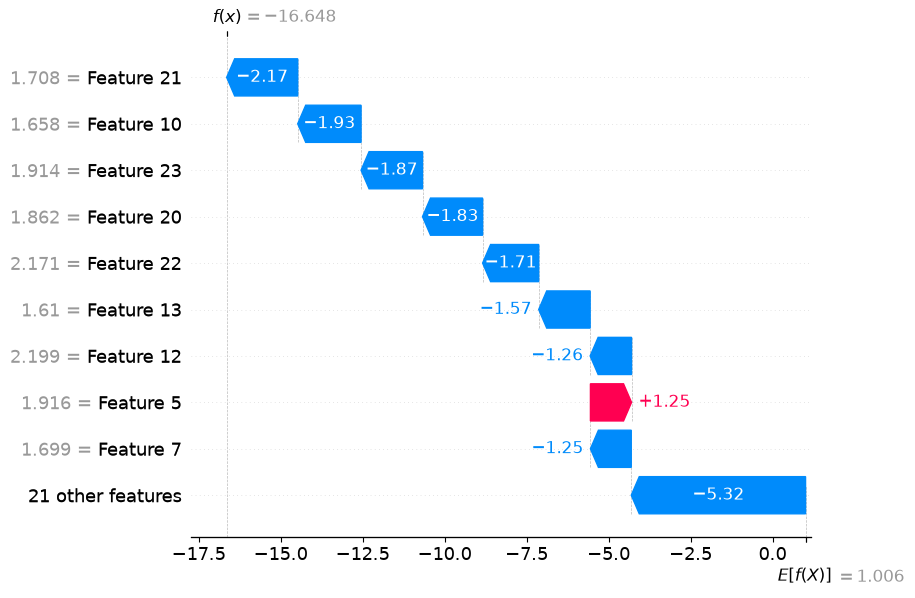

In [41]:
sample_index = 0

sample = X_test_scaled[sample_index:sample_index + 1]
sample_shap = explainer(sample)

shap.plots.waterfall(sample_shap[0])

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:30px 34px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:6px solid #5B537D;
    border-radius:22px;
    box-shadow:0 7px 20px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:23px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:16px;
">
📝 SHAP Interpretation
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
The global SHAP analysis shows that <b>mean compactness</b> was the most
influential feature overall, followed by <b>compactness error</b>,
<b>fractal dimension error</b>, <b>worst smoothness</b>, and
<b>worst compactness</b>.
</p>

<p>
For the selected individual prediction, several features pushed the
prediction toward the positive class. The strongest positive influences
were <b>mean compactness</b> and <b>compactness error</b>.
</p>

<p>
Other features pushed the prediction in the opposite direction. The
strongest negative influences were <b>worst texture</b>,
<b>radius error</b>, <b>worst area</b>, <b>worst radius</b>, and
<b>worst perimeter</b>.
</p>

<div style="
    margin-top:20px;
    padding:18px 20px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:15px;
">

<b style="color:#5B537D;">Key Takeaway:</b>
SHAP showed us both <b>which features matter most overall</b> and
<b>how individual features influenced a specific prediction</b>.
Some features pushed the prediction higher, while others pushed it lower,
and the final prediction resulted from their combined influence.

</div>

</div>
</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:24px 0;
    padding:32px 36px;
    background:linear-gradient(135deg,#F8F7FC 0%,#EEEAF6 100%);
    border:1px solid #D8D2E6;
    border-left:7px solid #5B537D;
    border-radius:22px;
    box-shadow:0 8px 22px rgba(91,83,125,0.10);
    font-family:Arial,sans-serif;
    color:#302C48;
">

<div style="
    font-size:26px;
    font-weight:700;
    color:#5B537D;
    margin-bottom:18px;
">
🚀 Step 4 — Complete the Sprint
</div>

<div style="font-size:15px;line-height:1.9;">

<p>
The final step is to prepare the Day 5 work for submission and complete
the sprint workflow.
</p>

<p>
Before committing the changes, we make sure that all Day 5 notebooks
run successfully without errors and that the evaluation results,
SMOTE comparison, threshold analysis, and SHAP explanations are properly
saved and documented.
</p>

<p>
We also verify that the <b>README</b> is complete and that all Sprint 3
files are stored in the correct Git branch.
</p>

<div style="
    margin-top:20px;
    padding:19px 22px;
    background:#FFFFFF;
    border:1px solid #DDD8E8;
    border-radius:16px;
">

<div style="font-size:18px;font-weight:700;color:#5B537D;margin-bottom:10px;">
✅ Final Checklist
</div>

<p style="margin:0;line-height:1.9;">
✔ All Day 5 notebooks run without errors<br>
✔ All results are saved and documented<br>
✔ README is complete<br>
✔ All Sprint 3 files are on the correct branch<br>
✔ Changes are committed and pushed<br>
✔ Pull Request is created or updated<br>
✔ Mentor review is completed<br>
✔ Requested changes are fixed<br>
✔ Pull Request is merged after approval
</p>

</div>

</div>
</div>